<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="https://www.um.es/documents/1073494/42130150/LogosimboloUMU-positivo.png" alt="UMU" style="height:200px; width:auto;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="https://www.upct.es/contenido/universidad/galeria/identidad-2021/logos/logos-upct/marca-upct/marca-principal/horizontal/azul.png" alt="UPCT" style="height:145px; width:auto;">
</div>

# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 2: Redes Convolucionales
### **Sesión 3/3: Segmentación de imágenes**

**Autores**: Antonio Martínez Sánchez, Juan Morales Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya

<div style="page-break-before: always;"></div>

### Contenidos
- [Requisitos](#requisitos)
- [Segmentación de imágenes](#segmentacion)
- [El dataset](#dataset)
- [Ejercicios](#ejercicios)
- [Ejercicios extra: reconstrucción 3D](#3D)

### Requisitos
<a class='anchor' id='requisitos'></a>

Se trabajará con notebooks de [Jupyter](https://jupyter.org/install) con código Python empleando como intérprete la última versión de [Miniconda](https://docs.anaconda.com/miniconda/). Se requiere la preinstalación (se recomienda utilizar [pip](https://pypi.org/project/pip/)) de los siguientes paquetes de Python:

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Scipy](https://pypi.org/project/scipy/) (computación científica)
- [Tensorflow](https://www.tensorflow.org/install/pip?hl=es-419#linux) que incluye a Keras (deep Learning)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (machine Learning)
- [Mrcfile](https://pypi.org/project/mrcfile/) (operaciones E/S para ficheros MRC)
- [Matplotlib](https://pypi.org/project/matplotlib/) and [Seaborn](https://pypi.org/project/seaborn/) (visualización de datos)

Además, para la visualización 3D se recomienda la utilización de [Paraview](https://www.paraview.org/).

### Segmentación de imágenes
<a class='anchor' id='segmentacion'></a>

En esta sección vamos a adaptar la red U-Net que construimos para restaurar imágenes en la sección anterior, en esta sección la usaremos para segmentar las imágenes contenidas en tomogramas. Un tomograma es una imagen volumétrica (3D) donde los píxeles, cuadrados, pasan a ser vóxeles, cubos. No obstante, ahora no vamos a procesar los tomogramas completos, si no que vamos a ir extrayendo cortes, imágenes 2D, para procesarlos de manera independiente. Trabajar en 3D suele requerir de unos recursos computacionales mayores de los que presenta un ordenador de escritorio. Un tomograma tiene tres ejes: X, Y y Z. Por lo que se pueden realizar cortes directos (no requieren de interpolaciones complejas): en los planos X-Y a lo largo de todas las coordenadas del eje Z, en los planos X-Z a lo largo de todas las coordenadas del eje Y y en los planos Y-Z a lo largo de todas las coordenadas del eje X. La siguiente imagen permite visualizar un ejemplo de corte en los planos X-Y, X-Z e Y-Z para un tomograma.

![TomoSlices](tomo_slices.png)

El problema de segmentación semántica consiste en clasificar, asignar una etiqueta, todos los píxeles (o vóxeles) de una imagen. Es una de las tareas más complejas en visión por computador, se necesita analizar un entorno amplio de las imágenes para determinar su contenido, pero a la vez hay que ser preciso en la asignación de las clases para cada píxel. En 2015 la arquitectura U-Net se diseñó para resolver el problema de la segmentación de imágenes y aún sigue siendo la más exitosa para resolver esta tarea.

### El dataset
<a class='anchor' id='dataset'></a>

El conjunto de datos de partida son dos tomogramas:
- Original: tomograma sintético generado con [PolNet](https://github.com/anmartinezs/polnet) simulando versión simplificada del contexto celular visualizado a escala nanométrica a través de un microscopio electrónico. Este tomograma contine elevados niveles de ruido y distorsiones generados durante los procesos de adquisición de la micrografías y la reconstrucción tomográfica.
- Ground truth: tomograma segmentado con 6 clases, 0-background, 1-membranas, 2-microtubulo, 3-complejo molecular de gran tamaño, 4-complejo molecular de tamaño medio, 5-proteina de membrana.

![Segmentation](segmentation.png)

Los tomogramas tienen formato MRC, así que se pueden abrir con la función presentada en la sesión anterior, y se encuentran en el directorio **imgs/tomo**. En la sección de [Ejercicios](ejercicios) no veremos un tomograma como una imagen 3D, si no como la acumulación de muchas imágenes. Gracias a esto podremos entrenar un modelo a partir de los datos de un solo tomograma sin requerir computación de altas prestaciones.

### Ejercicios
<a class='anchor' id='ejercicios'></a>

**E1:** Adapta la red empleada anteriormente para restauración de imágenes para resolver el problema de la segmentación semántica.

**E2:** Carga los tomogramas del dataset y genera un conjunto de imágenes 2D resultados cortar el tomograma en el plano X-Y (las dos primeras dimensiones) para todas la coordenadas del eje Z (la última dimensión).

**E3:** Entrena un modelo y evalúa sus prestaciones. 

**E4:** Visualiza un par de cortes para verificar los resultados numéricos comparando con el ground truth.

**E5:** Repite los ejercicios 2 e 3 pero esta vez generando un dataset mayor añadiendo los cortes en los planos X-Z, a lo largo del eje Y, e Y-Z, a lo largo del eje X. 

### Ejercicios extra: reconstrucción 3D
<a class='anchor' id='3D'></a>

Se proponen unos ejercicios extra que permitirán obtener hasta **dos puntos adicionales** en la evaluación de la práctica 2. Solo sería necesario **hacer uno** de ellos. En ambos ejercicios, trataremos de obtener por vías diferentes segmentaciones completas (en 3D) de los tomogramas, en lugar de simples cortes en 2D.

![Segmentacion3D](seg_3d.png)

**Extra 1:** Con el último modelo entrenado, procesa todo el tomograma y reconstruye la segmentación en 3D. Para ello tendrás que reconstruir 3 tomogramas, uno para cada uno de los tres tipos de cortes X-Y, X-Z e Y-Z, y después definir un criterio fusionar los tres tomogramas en uno solo de tal modo que a un vóxel solo le corresponda una clase.


<!-- **Extra 2:** Para segmentar tomogramas, en lugar de trabajar con cortes 2D como hemos hecho en la sección anterior, tiene más sentido trabajar directamente en 3D. No obstante, entrenar modelos 3D suele ser mucho más costoso computacionalmente y además se requieren más datos de entrenamiento puesto que las redes tienen más parámetros. En la práctica, se requieren sistemas de computación de altas prestaciones para entrenar modelos y procesar datos en 3D. Este ejercicio propone entrenar un modelo para la segmentación directa de los tomogramas en 3D. Para el entrenamiento se proporcionan 10 tomogramas, más los 10 tomogramas de ground truth correspondientes, accesibles a través del servicio de cálculo científico [ATLAS](https://scc.atica.um.es/intro.html) de la Universidad de Murcia. El entrenamiento y procesamiento tiene que realizarse en los computadores de este servicio. -->

In [1]:
# ============================================================
# Imports
# ============================================================
import numpy as np
import mrcfile
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    concatenate,
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

In [2]:
# ============================================================
# Funciones auxliares
# ============================================================

def load_mrc(fname, mmap=False, no_saxes=True):
    """Load an input MRC file as ndarray."""
    if mmap:
        mrc = mrcfile.mmap(fname, permissive=True, mode="r+")
    else:
        mrc = mrcfile.open(fname, permissive=True, mode="r+")
    if no_saxes:
        return np.swapaxes(mrc.data, 0, 2)
    return mrc.data

In [3]:
# ============================================================
# E1: Adapatar la U-Net para segmentación semántica
# ============================================================
# Cambios respecto a restauración:
# - La salida tiene N_CLASSES canales en lugar de 1
# - Activación final: softmax (clasificación multiclase por píxel)
# - Función de pérdida: sparse_categorical_crossentropy
#   (las etiquetas son enteros 0..5, no one-hot)

N_CLASSES = 6 # 0-background, 1-membranas, 2-microtubulo, 3-complejo grande, 4-complejo medio, 5-poteína membrana

def build_unet_segmentation(input_shape, n_classes=N_CLASSES):
    inputs = Input(shape=input_shape)

    # --- Encoder ---
    # Bloque 1: 32 filtros
    c1 = Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    c1 = Conv2D(32, (3, 3), activation="relu", padding="same")(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    # Bloque 2: 64 filtros
    c2 = Conv2D(64, (3, 3), activation="relu", padding="same")(p1)
    c2 = Conv2D(64, (3, 3), activation="relu", padding="same")(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # Bloque 3: 128 filtros
    c3 = Conv2D(128, (3, 3), activation="relu", padding="same")(p2)
    c3 = Conv2D(128, (3, 3), activation="relu", padding="same")(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    # --- Cuello de botella ---: 256 filtros
    bn = Conv2D(256, (3, 3), activation="relu", padding="same")(p3)
    bn = Conv2D(256, (3, 3), activation="relu", padding="same")(bn)

    # --- Decoder ---
    # Bloque 4: 128 filtros
    u4 = UpSampling2D((2, 2))(bn)
    u4 = concatenate([u4, c3])
    c4 = Conv2D(128, (3, 3), activation="relu", padding="same")(u4)
    c4 = Conv2D(128, (3, 3), activation="relu", padding="same")(c4)

    # Bloque 5: 64 filtros
    u5 = UpSampling2D((2, 2))(c4)
    u5 = concatenate([u5, c2])
    c5 = Conv2D(64, (3, 3), activation="relu", padding="same")(u5)
    c5 = Conv2D(64, (3, 3), activation="relu", padding="same")(c5)

    # Bloque 6: 32 filtros
    u6 = UpSampling2D((2, 2))(c5)
    u6 = concatenate([u6, c1])
    c6 = Conv2D(32, (3, 3), activation="relu", padding="same")(u6)
    c6 = Conv2D(32, (3, 3), activation="relu", padding="same")(c6)

    # Capa de salida: n_classes filtros, activación softmax (clasificación por píxel)
    outputs = Conv2D(n_classes, (1, 1), activation="softmax", padding="same")(c6)

    model = Model(inputs=inputs, outputs=outputs)
    return model

Tomograma original shape: (400, 400, 100)
Tomograma ground truth shape: (400, 400, 100)
Clases únicas en ground truth: [0. 1. 2. 3. 4. 5.]

Cortes X-Y generados: 100
Tamaño de cada corte: 400×400
Tensor de entrada (X): (100, 400, 400, 1)
Tensor de etiquetas (Y): (100, 400, 400, 1)


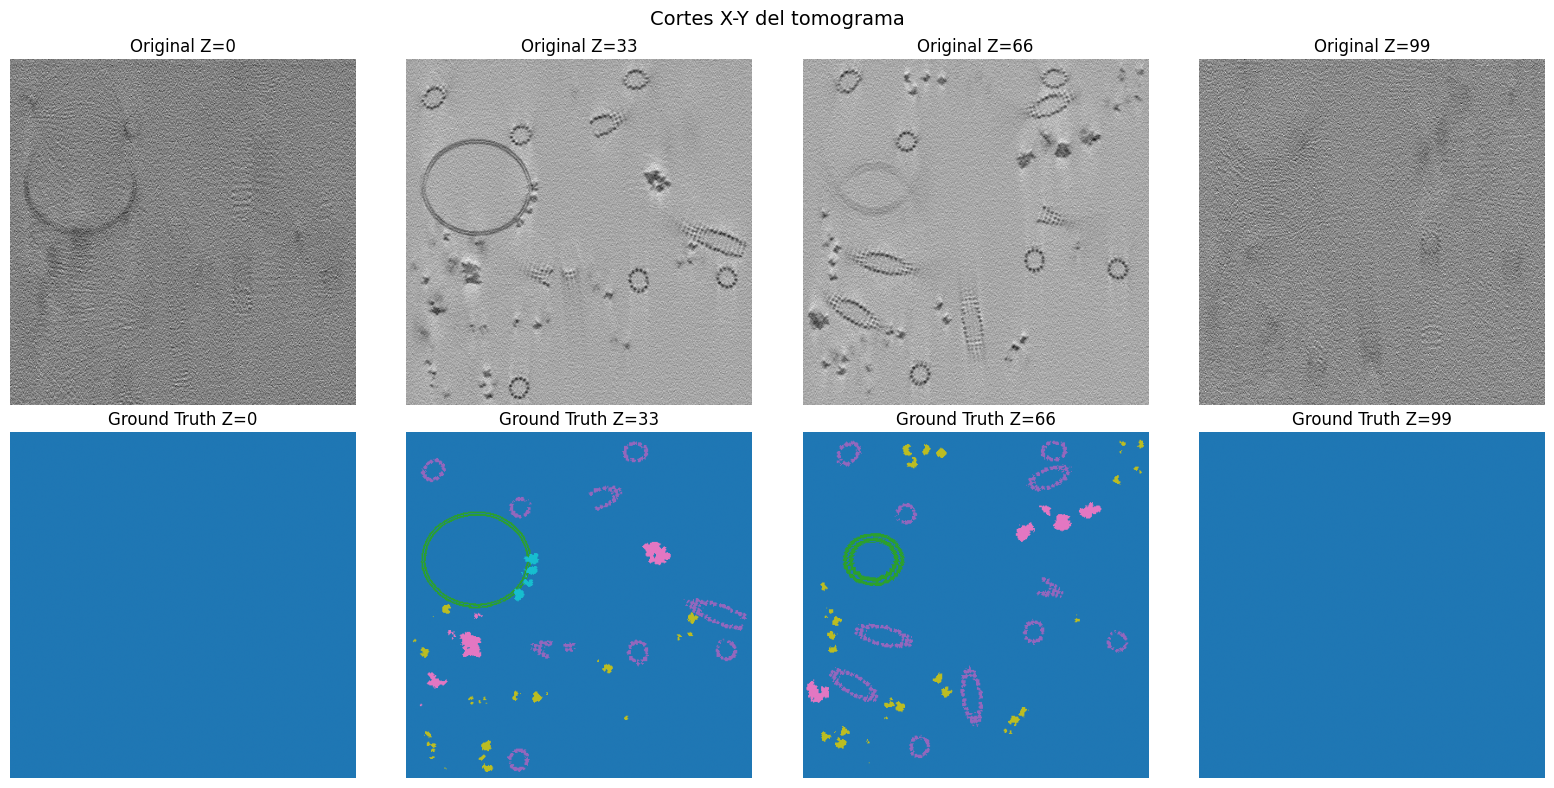

In [4]:
# ============================================================
# E2: Cargar tomogramas y generar cortes X-Y a lo largo de Z
# ============================================================

tomo_dir = "./imgs/tomo/"

# Cargar tomograma original (ruidoso) y ground truth (segmentado)
tomo_original = load_mrc(os.path.join(tomo_dir, "tomo.mrc"))
tomo_gt = load_mrc(os.path.join(tomo_dir, "tomo_gt.mrc"))

print(f"Tomograma original shape: {tomo_original.shape}")
print(f"Tomograma ground truth shape: {tomo_gt.shape}")
print(f"Clases únicas en ground truth: {np.unique(tomo_gt)}")

# Generar cortes en el plano X-Y (dos primeras dimensiones) para cada Z
# El tomograma tiene shape (X, Y, Z) tras load_mrc con np_saxes=True
n_x, n_y, n_z = tomo_original.shape

slices_xy_input = []
slices_xy_label = []

for z in range(n_z):
    slice_input = tomo_original[:, :, z]
    slice_label = tomo_gt[:, :, z]
    slices_xy_input.append(slice_input)
    slices_xy_label.append(slice_label)

X_xy = np.array(slices_xy_input, dtype=np.float32)
Y_xy = np.array(slices_xy_label, dtype=np.float32)

# Añadir dimensión de canal
X_xy = X_xy[..., np.newaxis]    # (N, H, W, 1)
Y_xy = Y_xy[..., np.newaxis]    # (N, H, W, 1) - etiquetas enteras

print(f"\nCortes X-Y generados: {X_xy.shape[0]}")
print(f"Tamaño de cada corte: {X_xy.shape[1]}×{X_xy.shape[2]}")
print(f"Tensor de entrada (X): {X_xy.shape}")
print(f"Tensor de etiquetas (Y): {Y_xy.shape}")

# Visualizar algunos cortes de ejemplo
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_indices = np.linspace(0, n_z - 1, 4, dtype=int)
for i, idx in enumerate(sample_indices):
    axes[0, i].imshow(X_xy[idx, :, :, 0], cmap="gray")
    axes[0, i].set_title(f"Original Z={idx}")
    axes[0, i].axis("off")
    axes[1, i].imshow(Y_xy[idx, :, :, 0], cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
    axes[1, i].set_title(f"Ground Truth Z={idx}")
    axes[1, i].axis("off")
plt.suptitle("Cortes X-Y del tomograma", fontsize=14)
plt.tight_layout()
plt.show()

Dimensiones de los cortes: 400 × 400
Entrenamiento:  80 cortes
Validación:     20 cortes


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 400, 400,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 400, 400,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 400, 400,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 200, 200,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 200, 200,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 200, 200,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 100, 100,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 100, 100,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 100, 100,  │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 50, 50,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 50, 50,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 50, 50,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 100, 100,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100, 100,  │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 100, 100,  │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 100, 100,  │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 200, 200,  │          0 │ conv2d_9[0][0]  

 Total params: 1,946,470 (7.43 MB)

 Trainable params: 1,946,470 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.9323 - loss: 0.3767 - val_accuracy: 0.9708 - val_loss: 0.1575
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9702 - loss: 0.1051 - val_accuracy: 0.9708 - val_loss: 0.1129
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9714 - loss: 0.0909 - val_accuracy: 0.9746 - val_loss: 0.0759
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9761 - loss: 0.0709 - val_accuracy: 0.9789 - val_loss: 0.0595
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9793 - loss: 0.0581 - val_accuracy: 0.9816 - val_loss: 0.0514
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9820 - loss: 0.0498 - val_accuracy: 0.9826 - val_loss: 0.0470
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9842 - loss: 0.0407 - val_accuracy: 0.9847 - val_loss: 0.0433
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9813 - loss: 0.0572 - val_accuracy: 0.

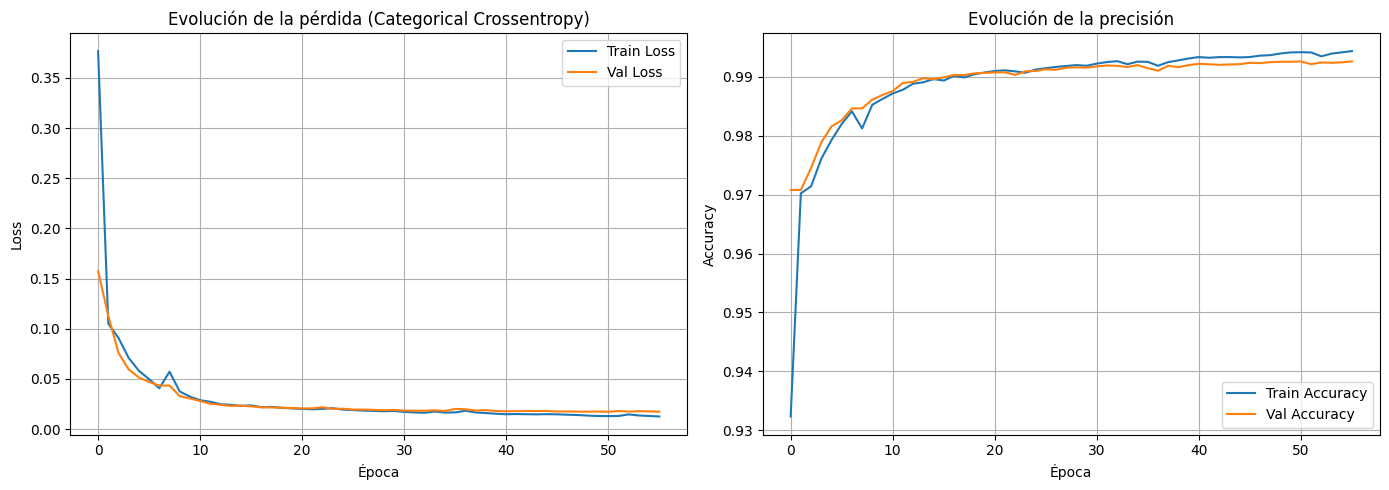

In [5]:
# ============================================================
# E3: Entrenar modelo y evaluar prestaciones (solo cortes X-Y)
# ============================================================

# Verificar que las dimensiones espaciales son divisibles por 8 (3 MaxPool de factor 2)
h, w = X_xy.shape[1], X_xy.shape[2]
print(f"Dimensiones de los cortes: {h} × {w}")
assert h % 8 == 0 and w % 8 == 0, (
    f"Las dimensiones ({h}×{w}) deben ser divisibles por 8 para 3 niveles de MaxPooling."
)

# Partición 80/20
X_train, X_val, Y_train, Y_val = train_test_split(
    X_xy, Y_xy, test_size=0.2, random_state=42, shuffle=True
)

print(f"Entrenamiento:  {X_train.shape[0]} cortes")
print(f"Validación:     {X_val.shape[0]} cortes")

# Construir modelo
input_shape = (h, w, 1)
model_seg = build_unet_segmentation(input_shape, n_classes=N_CLASSES)
model_seg.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_seg.summary()

# Entrenar con early stopping
early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

history = model_seg.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=100,
    batch_size=2,
    callbacks=[early_stop],
    verbose=1,
)

# Evaluar
val_loss, val_acc = model_seg.evaluate(X_val, Y_val, batch_size=2, verbose=0)
print("\nResultados en validación:")
print(f"  Loss: {val_loss:.4f}")
print(f"  Accuracy: {val_acc:.4f}")

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].set_title("Evolución de la pérdida (Categorical Crossentropy)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Evolución de la precisión")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# E4: Validación cortes comparando predicción vs ground truth
# ============================================================

# Predecir sobre el conjunto de validación
Y_pred_probs = model_seg.predict(X_val)
Y_pred = np.argmax(Y_pred_probs, axis=-1)  # (N, H, W)

# Seleccionar algunos ejemplos para visualizar
n_examples = 4
example_indices = np.random.choice(X_val.shape[0], n_examples, replace=False)

fig, axes = plt.subplots(n_examples, 3, figsize=(15, 5 * n_examples))

for i, idx in enumerate(example_indices):
    # Imagen original
    axes[i, 0].imshow(X_val[idx, :, :, 0], cmap="gray")
    axes[i, 0].set_title(f"Entrada (ruidosa) #{idx}")
    axes[i, 0].axis('off')

    # Ground truth
    axes[i, 1].imshow(Y_val[idx, :, :, 0], cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
    axes[i, 1].set_title(f"Ground Truth #{idx}")
    axes[i, 1].axis('off')

    # Predicción
    axes[i, 2].imshow(Y_pred[idx, :, :], cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
    axes[i, 2].set_title(f"Predicción #{idx}")
    axes[i, 2].axis('off')

plt.suptitle("Comparación: Entrada vs Ground Truth vs Predicción", fontsize=14)
plt.tight_layout()
plt.show()

# Matriz de confusión
from sklearn.metrics import classification_report, confusion_matrix

y_true_flat = Y_val[:, :, :, 0].flatten().astype(int)
y_pred_flat = Y_pred.flatten()

class_names = [
    "Background",
    "Membranas",
    "Microtúbulo",
    "Complejo grande",
    "Complejo medio",
    "Prot. membrana",
]

print("\nInforme de clasificación (validación):")
print(classification_report(y_true_flat, y_pred_flat, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true_flat, y_pred_flat)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

InternalError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "/home/pyros05/anaconda3/envs/DL/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/home/pyros05/anaconda3/envs/DL/lib/python3.10/runpy.py", line 86, in _run_code

  File "/home/pyros05/anaconda3/envs/DL/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/pyros05/anaconda3/envs/DL/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/pyros05/anaconda3/envs/DL/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/pyros05/anaconda3/envs/DL/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/pyros05/anaconda3/envs/DL/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  File "/home/pyros05/anaconda3/envs/DL/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once

  

In [ ]:
# ============================================================
# E5: Ampliar dataset con cortes X-Z (a lo largo de Y) e Y-Z (a lo largo de X)
# ============================================================

# Cortes X-Z: fijar Y, variar X y Z
slices_xz_input = []
slices_xz_label = []
for y in range(n_y):
    slices_xz_input.append(tomo_original[:, y, :])
    slices_xz_label.append(tomo_gt[:, y, :])

X_xz = np.array(slices_xz_input, dtype=np.float32)[..., np.newaxis]
Y_xz = np.array(slices_xz_label, dtype=np.float32)[..., np.newaxis]

# Cortes Y-Z: fijar X, variar Y y Z
slices_yz_input = []
slices_yz_label = []
for x in range(n_x):
    slices_yz_input.append(tomo_original[x, :, :])
    slices_yz_label.append(tomo_gt[x, :, :])

X_yz = np.array(slices_yz_input, dtype=np.float32)[..., np.newaxis]
Y_yz = np.array(slices_yz_label, dtype=np.float32)[..., np.newaxis]

print(f"Cortes X-Y: {X_xy.shape}")
print(f"Cortes X-Z: {X_xz.shape}")
print(f"Cortes Y-Z: {X_yz.shape}")

# Verificar que todas las dimensiones son compatibles (divisibles por 8)
# Si no lo son, necesitamos recortar o hacer padding
def pad_to_multiple(arr, multiple=8):
    """Pad array spatial dimensions to nearest multiple."""
    _, h, w, c = arr.shape
    new_h = int(np.ceil(h / multiple) * multiple)
    new_w = int(np.ceil(w / multiple) * multiple)
    if new_h == h and new_w == w:
        return arr
    padded = np.zeros((arr.shape[0], new_h, new_w, c), dtype=arr.dtype)
    padded[:, :h, :w, :] = arr
    return padded

X_xz_pad = pad_to_multiple(X_xz)
Y_xz_pad = pad_to_multiple(Y_xz)
X_yz_pad = pad_to_multiple(X_yz)
Y_yz_pad = pad_to_multiple(Y_yz)
X_xy_pad = pad_to_multiple(X_xy)
Y_xy_pad = pad_to_multiple(Y_xy)

print("\nTras padding:")
print(f"    X-Y: {X_xy_pad.shape}")
print(f"    X-Z: {X_xz_pad.shape}")
print(f"    Y-Z: {X_yz_pad.shape}")

# Como los cortes pueden tener diferentes tamaños espaciales,
# necesitamos redimensionar todos al mismo tamaño o entrenar con
# el tamaño máximo común. Usamos padding al tamaño máximo.
max_h = max(X_xy_pad.shape[1], X_xz_pad.shape[1], X_yz_pad.shape[1])
max_w = max(X_xy_pad.shape[2], X_xz_pad.shape[2], X_yz_pad.shape[2])

def pad_to_size(arr, target_h, target_w):
    """Pad array to target spatial dimensions."""
    _, h, w, c = arr.shape
    if h == target_h and w == target_w:
        return arr
    padded = np.zeros((arr.shape[0], target_h, target_w, c), dtype=arr.dtype)
    padded[:, :h, :w, :] = arr
    return padded

X_xy_final = pad_to_size(X_xy_pad, max_h, max_w)
Y_xy_final = pad_to_size(Y_xy_pad, max_h, max_w)
X_xz_final = pad_to_size(X_xz_pad, max_h, max_w)
Y_xz_final = pad_to_size(Y_xz_pad, max_h, max_w)
X_yz_final = pad_to_size(X_yz_pad, max_h, max_w)
Y_yz_final = pad_to_size(Y_yz_pad, max_h, max_w)

# Concatenar todos los cortes
X_all = np.concatenate([X_xy_final, X_xz_final, X_yz_final], axis=0)
Y_all = np.concatenate([Y_xy_final, Y_xz_final, Y_yz_final], axis=0)

print("\nDataset combinado:")
print(f"    X_all: {X_all.shape}")
print(f"    Y_all: {Y_all.shape}")
print(f"    Total cortes: {X_all.shape[0]}")

# Partición 80/20
X_train_all, X_val_all, Y_train_all, Y_val_all = train_test_split(
    X_all, Y_all, test_size=0.2, random_state=42, shuffle=True
)

print(f"\nEntrenamiento: {X_train_all.shape[0]} cortes")
print(f"Validación:    {X_val_all.shape[0]} cortes")

In [ ]:
# ============================================================
# E5 (cont.): Entrenar modelo con dataset ampliado
# ============================================================

# Construir modelo nuevo con las dimensiones correctas
input_shape_all = (max_h, max_w, 1)
model_seg_all = build_unet_segmentation(input_shape_all, n_classes=N_CLASSES)
model_seg_all.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Input shape del modelo: {input_shape_all}")
model_seg_all.summary()

# Entrenar con early sotpping
early_stop_all = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

history_all = model_seg_all.fit(
    X_train_all,
    Y_train_all,
    validation_data=(X_val_all, Y_val_all),
    epochs=100,
    batch_size=2,
    callbacks=[early_stop_all],
    verbose=1,
)

# Evaluar
val_loss_all, val_acc_all = model_seg_all.evaluate(X_val_all, Y_val_all, verbose=0)
print("\nResultados en validación (dataset ampliado):")
print(f"    Loss: {val_loss_all:.4f}")
print(f"    Accuracy: {val_acc_all:.4f}")

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_all.history["loss"], label="Train Loss")
axes[0].plot(history_all.history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].set_title("Pérdida - Dataset ampliado (3 planos)")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_all.history["accuracy"], label="Train Accuracy")
axes[1].plot(history_all.history["val_accuracy"], label="Val Accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Precisión - Dataset ampliado (3 planos)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Visualizar ejemplos
Y_pred_all_probs = model_seg_all.predict(X_val_all)
Y_pred_all = np.argmax(Y_pred_all_probs, axis=-1)

n_examples = 4
example_indices = np.random.choice(X_val_all.shape[0], n_examples, replace=False)

fig, axes = plt.subplots(n_examples, 3, figsize=(15, 5 * n_examples))
for i, idx in enumerate(example_indices):
    axes[i, 0].imshow(X_val_all[idx, :, :, 0], cmap="gray")
    axes[i, 0].set_title(f"Entrada #{idx}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(Y_val_all[idx, :, :, 0], cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
    axes[i, 1].set_title(f"Ground Truth #{idx}")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(Y_pred_all[idx, :, :], cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
    axes[i, 2].set_title(f"Predicción #{idx}")
    axes[i, 2].axis('off')

plt.suptitle("Dataset ampliado: Entrada vs Ground Truth vs Predicción", fontsize=14)
plt.tight_layout()
plt.show()

# Informe de clasificación
y_true_all_flat = Y_val_all[:, :, :, 0].flatten().astype(int)
y_pred_all_flat = Y_pred_all.flatten()

print("\nInforme de clasificación (dataset ampliado):")
print(classification_report(y_true_all_flat, y_pred_all_flat, target_names=class_names, zero_division=0))

In [ ]:
# ============================================================
# Extra 1: Reconstrucción 3D del tomograma segmentado
# ============================================================
# Procesar el tomograma completo con los 3 tipos de cortes y
# fusionar las predicciones mediante votación mayoritaria por vóxel.

print("Procesando tomograma completo para reconstrucción 3D...")
print(f"Dimensiones del tomograma: {tomo_original.shape} (X={n_x}, Y={n_y}, Z={n_z})")

# --- Segmentación por cortes X-Y ---
print("\n1. Procesando cortes X-Y...")
tomo_pred_xy = np.zeros((n_x, n_y, n_z, N_CLASSES), dtype=np.float32)

for z in range(n_z):
    slice_in = tomo_original[:, :, z].astype(np.float32)
    # Pad al tamaño del modelo
    padded = np.zeros((max_h, max_w), dtype=np.float32)
    padded[:n_x, :n_y] = slice_in
    padded = padded[np.newaxis, ..., np.newaxis]  # (1, H, W, 1)
    pred = model_seg_all.predict(padded, verbose=0)  # (1, H, W, N_CLASSES)
    tomo_pred_xy[:, :, z, :] = pred[0, :n_x, :n_y, :]

print("  Hecho.")

# --- Segmentación por cortes X-Z ---
print("2. Procesando cortes X-Z...")
tomo_pred_xz = np.zeros((n_x, n_y, n_z, N_CLASSES), dtype=np.float32)

for y in range(n_y):
    slice_in = tomo_original[:, y, :].astype(np.float32)
    padded = np.zeros((max_h, max_w), dtype=np.float32)
    padded[:n_x, :n_z] = slice_in
    padded = padded[np.newaxis, ..., np.newaxis]
    pred = model_seg_all.predict(padded, verbose=0)
    tomo_pred_xz[:, y, :, :] = pred[0, :n_x, :n_z, :]

print("  Hecho.")

# --- Segmentación por cortes Y-Z ---
print("3. Procesando cortes Y-Z...")
tomo_pred_yz = np.zeros((n_x, n_y, n_z, N_CLASSES), dtype=np.float32)

for x in range(n_x):
    slice_in = tomo_original[x, :, :].astype(np.float32)
    padded = np.zeros((max_h, max_w), dtype=np.float32)
    padded[:n_y, :n_z] = slice_in
    padded = padded[np.newaxis, ..., np.newaxis]
    pred = model_seg_all.predict(padded, verbose=0)
    tomo_pred_yz[x, :, :, :] = pred[0, :n_y, :n_z, :]

print("  Hecho.")

# --- Fusión por votación: promedio de probabilidades y argmax ---
print("\n4. Fusionando predicciones (promedio de probabilidades + argmax)...")
tomo_pred_avg = (tomo_pred_xy + tomo_pred_xz + tomo_pred_yz) / 3.0
tomo_seg_3d = np.argmax(tomo_pred_avg, axis=-1).astype(np.int8)

print(f"   Tomograma segmentado 3D shape: {tomo_seg_3d.shape}")
print(f"   Clases presentes: {np.unique(tomo_seg_3d)}")

# Calcular accuracy global en 3D
gt_flat = tomo_gt.flatten().astype(int)
pred_flat = tomo_seg_3d.flatten()
accuracy_3d = np.mean(gt_flat == pred_flat)
print(f"\n   Accuracy global 3D: {accuracy_3d:.4f}")

# Visualizar algunos cortes del resultado 3D
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
z_mid = n_z // 2
y_mid = n_y // 2
x_mid = n_x // 2

# Corte X-Y en Z medio
axes[0, 0].imshow(tomo_original[:, :, z_mid], cmap="gray")
axes[0, 0].set_title(f"Original X-Y (Z={z_mid})")
axes[0, 1].imshow(tomo_gt[:, :, z_mid], cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
axes[0, 1].set_title(f"Ground Truth X-Y (Z={z_mid})")
axes[0, 2].imshow(tomo_seg_3d[:, :, z_mid], cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
axes[0, 2].set_title(f"Predicción 3D X-Y (Z={z_mid})")

# Corte X-Z en Y medio
axes[1, 0].imshow(tomo_original[:, y_mid, :], cmap="gray")
axes[1, 0].set_title(f"Original X-Z (Y={y_mid})")
axes[1, 1].imshow(tomo_gt[:, y_mid, :], cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
axes[1, 1].set_title(f"Ground Truth X-Z (Y={y_mid})")
axes[1, 2].imshow(tomo_seg_3d[:, y_mid, :], cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
axes[1, 2].set_title(f"Predicción 3D X-Z (Y={y_mid})")

# Corte Y-Z en X medio
axes[2, 0].imshow(tomo_original[x_mid, :, :], cmap="gray")
axes[2, 0].set_title(f"Original Y-Z (X={x_mid})")
axes[2, 1].imshow(tomo_gt[x_mid, :, :], cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
axes[2, 1].set_title(f"Ground Truth Y-Z (X={x_mid})")
axes[2, 2].imshow(tomo_seg_3d[x_mid, :, :], cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
axes[2, 2].set_title(f"Predicción 3D Y-Z (X={x_mid})")

for ax in axes.flat:
    ax.axis("off")

plt.suptitle("Reconstrucción 3D: comparación en los 3 planos de corte", fontsize=14)
plt.tight_layout()
plt.show()

# Guardar el tomograma segmentado en formato MRC
output_path = os.path.join(tomo_dir, "tomo_segmented_3d.mrc")
with mrcfile.new(output_path, overwrite=True) as mrc:
    mrc.set_data(np.swapaxes(tomo_seg_3d, 0, 2).astype(np.float32))
print(f"\nTomograma segmentado guardado en: {output_path}")